In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nhts_data = pd.read_csv('NHTS(in).csv')
ngsim_data = pd.read_csv('NGSIM(in).csv')

Bar Chart: Fuel Type

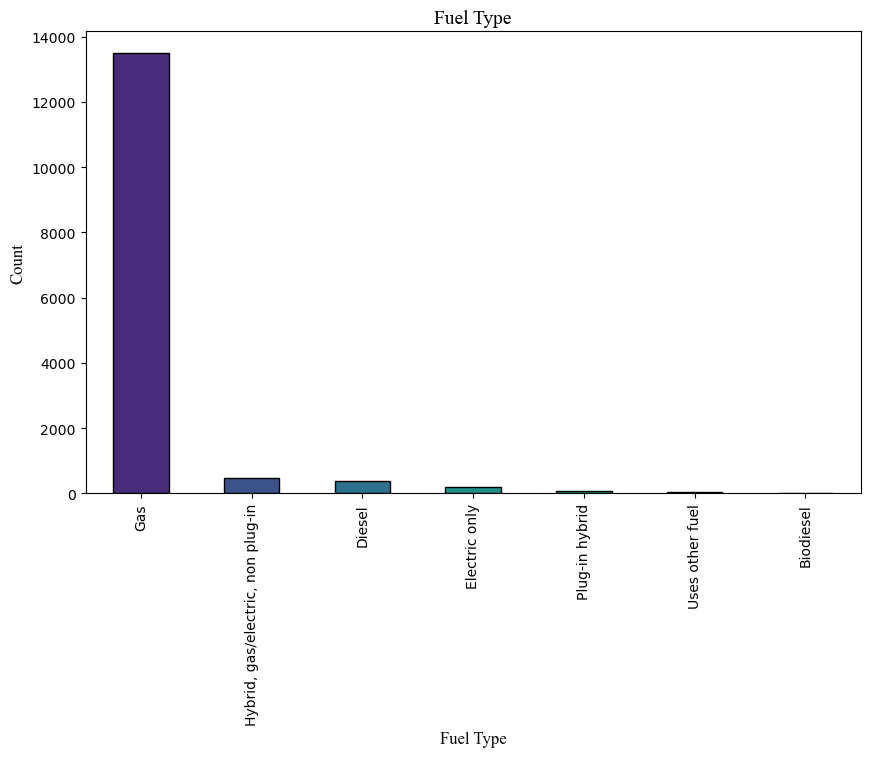

In [16]:
# Simple bar chart: count of vehicles by fuel type
# First we need to count the values, then plot
## Step 1: count the number of vehicles by fuel type
# hint: use .value_counts()
fuel_counts = nhts_data['fuel_type'].value_counts().dropna()
## Step 2: create the bar plot
plt.figure(figsize = (10, 6))
fuel_counts.plot(kind = 'bar', edgecolor = 'black', color = sns.color_palette('viridis', len(fuel_counts)))
## Step 3: add labels and customization
plt.xlabel('Fuel Type', fontname="Times New Roman", fontsize = 12)
plt.ylabel('Count', fontname="Times New Roman", fontsize = 12)
plt.title('Fuel Type', fontname="Times New Roman", fontsize = 14)
## Step 4: show the plot
plt.show()


Histogram: Urban vs Rural Vehicle Age

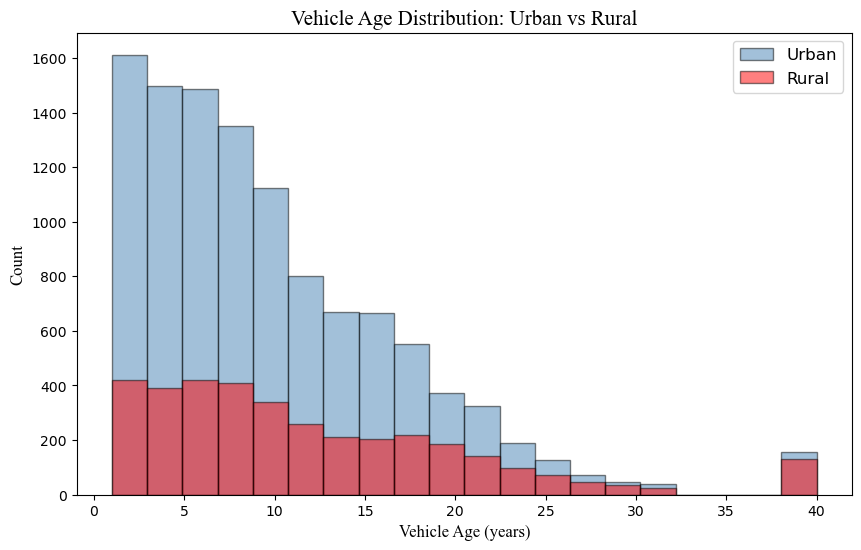

In [ ]:

# We need to filter the data first, then plot each group separately
## Step 1: tell Python you are making a figure
plt.figure(figsize = (10, 6))
## Step 2: filter and plot Urban vehicle ages
urban_ages = nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
plt.hist(urban_ages, bins = 20, alpha = .5, label = 'Urban', color = 'steelblue', edgecolor = 'black')
## Step 3: filter and plot Rural vehicle ages on the same figure
rural_ages = nhts_data[nhts_data['household_location'] == 'Rural']['vehicle_age']
plt.hist(rural_ages, bins = 20, alpha = .5, label = 'Rural', color = 'red', edgecolor = 'black')
## Step 4: add labels, title, and legend
plt.xlabel('Vehicle Age (years)', fontname="Times New Roman", fontsize = 12)
plt.ylabel('Count', fontname="Times New Roman", fontsize = 12)
plt.title('Vehicle Age Distribution: Urban vs Rural', fontname="Times New Roman", fontsize = 15)
plt.legend(fontsize=12)
plt.show()


Bar Plot: Vehicle Make vs Age

<Figure size 4500x2500 with 0 Axes>

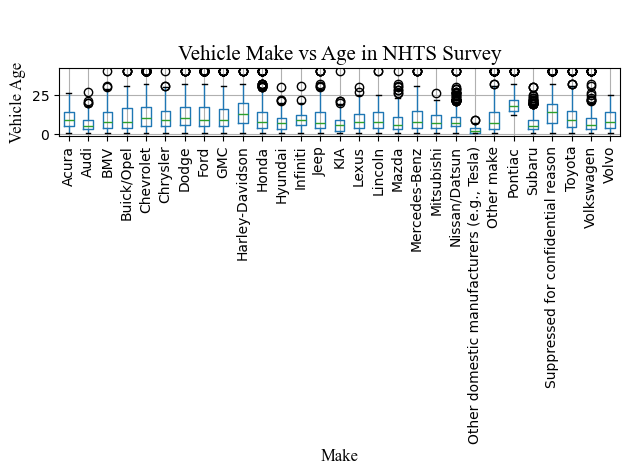

In [ ]:

## Step 1: tell Python you are making a figure and what size you want the figure to be
plt.figure(figsize = (45, 25))
## Step 2: call the type of plot and tell the function what variables you want to plot
boxplot = nhts_data.boxplot(column = 'vehicle_age', by = 'make')
## Step 3: add customization to the plot
plt.xticks(rotation=90)
plt.xlabel('Make', fontname="Times New Roman", fontsize = 12)
plt.ylabel('Vehicle Age', fontname="Times New Roman", fontsize = 12)
plt.title('Vehicle Make vs Age in NHTS Survey', fontname="Times New Roman", fontsize = 15)
plt.suptitle(' ')
## Step 4: tell python to show the plot
plt.tight_layout()
plt.show()


Time Series 1: Leader Speed vs Time

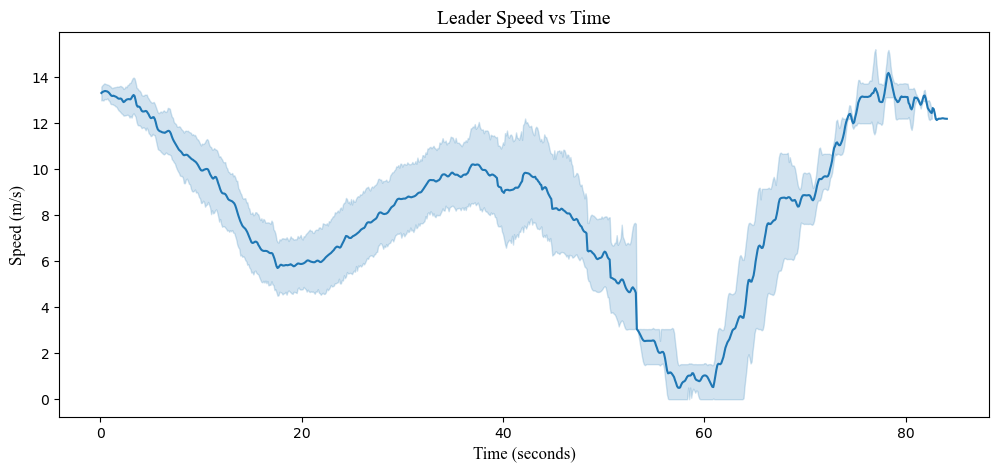

In [ ]:

plt.figure(figsize = (12,5))
sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['leader_speed(m/s)'])
plt.xlabel('Time (seconds)', fontname="Times New Roman", fontsize = 12)
plt.ylabel('Speed (m/s)', fontname="Times New Roman", fontsize = 12)
plt.title('Leader Speed vs Time', fontname="Times New Roman", fontsize = 14)
plt.show()


Time Series 2: Leader Position vs Time

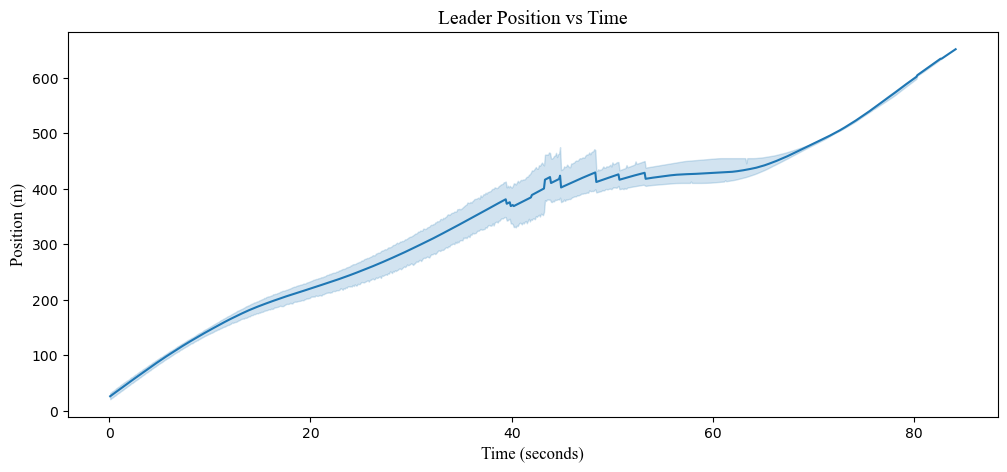

In [ ]:

plt.figure(figsize = (12,5))
sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['leader_position(m)'])
plt.xlabel('Time (seconds)', fontname="Times New Roman", fontsize = 12)
plt.ylabel('Position (m)', fontname="Times New Roman", fontsize = 12)
plt.title('Leader Position vs Time', fontname="Times New Roman", fontsize = 14)
plt.show()


Simulation Study

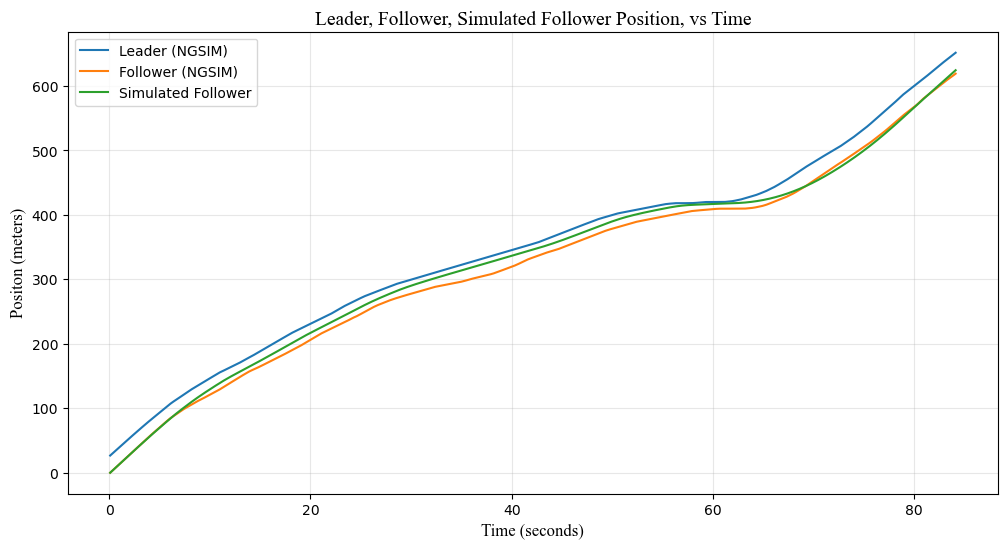

In [22]:
#------ Acceleration Function ------#

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    
    return acceleration

#------ Trajectory ------#

# Load the NGSIM data to get the leader vehicle trajectory
ngsim_data = pd.read_csv('NGSIM(in).csv')

# Select a trajectory pair
trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop = True)

# Extract the leader's position and speed over time
time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

# Identifying the time step in our data
dt = 0.1 # seconds

#------ Parameters ------#

v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)                 # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)         # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)            # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)              # simulated follower acceleration; we will create a vector with all zeroes  as a start
  
# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]        #this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]              #this makes the starting value [0] same as the follower vehicle speed

#------ Simulation ------#

for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]

    # Step 3: Use the IDM function to calculate acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i] * dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt

#------ Plot ------#

plt.figure(figsize = (12,6))
plt.plot(time_data, leader_position, label = 'Leader (NGSIM)')
plt.plot(time_data, data_subset['follower_position(m)'].values, label = 'Follower (NGSIM)')
plt.plot(time_data, sim_position, label = 'Simulated Follower')
plt.xlabel('Time (seconds)', fontname="Times New Roman", fontsize = 12)
plt.ylabel('Positon (meters)', fontname="Times New Roman", fontsize = 12)
plt.legend()
plt.grid(True, alpha = .3)
plt.title('Leader, Follower, Simulated Follower Position, vs Time', fontname="Times New Roman", fontsize = 14)
plt.show()